# Sentiment Analysis with LSTM

Same dataset as the SimpleRNN notebook, but we swap the recurrent layer for an **LSTM** to get better accuracy.


In [2]:
import pandas as pd

df = pd.read_csv(r'/home/chris/Documents/Broadway Python/Lesson 1/Deep Learning/RNN/data 1.csv')
df.head(4)

,sentence,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1


In [3]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

for w in ["not", "no", "nor", "never", "n't"]:
    stop_words.discard(w)

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df["sentence"] = df["sentence"].apply(preprocess)

[nltk_data] Downloading package stopwords to /home/chris/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
from sklearn.model_selection import train_test_split

x = df['sentence']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (800,)  X_test: (200,)


In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

num_words = 10000    
maxlen    = 20       

tokenizer = Tokenizer(num_words=num_words, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=maxlen, truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  padding='post', maxlen=maxlen, truncating='post')

vocab_size = min(num_words, len(tokenizer.word_index) + 1)
print("vocab_size:", vocab_size)
print("sample:", X_train_pad[0])

I0000 00:00:1788411374.621760   21678 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788411374.622739   21678 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788411375.079369   21678 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788411377.996903   21678 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

vocab_size: 1679
sample: [115 654 164  97  46 655 116   0   0   0   0   0   0   0   0   0   0   0
   0   0]


## Load pretrained Word2Vec (Google News 300d)

In [ ]:
# import gensim.downloader as api
# import numpy as np

# w2v = api.load("word2vec-google-news-300")
# print("word2vec-google-news-300 loaded")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
word2vec-google-news-300 loaded


In [9]:
from gensim.models import KeyedVectors
import numpy as np

path = r"~/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz"
w2v = KeyedVectors.load_word2vec_format(path, binary=True)

embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))
hits, misses = 0, 0
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v:
        embedding_matrix[i] = w2v[word]
        hits += 1
    else:
        misses += 1
print(f"Embedding coverage: {hits} hits / {misses} misses")

Embedding coverage: 1613 hits / 65 misses


## Build the LSTM model

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(maxlen,)),

    # Pretrained Word2Vec embeddings (frozen)
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),

    Dropout(0.3),

    # Stacked LSTM: first returns sequences, second returns final state
    LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
    LSTM(32, dropout=0.3, recurrent_dropout=0.2),

    Dense(32, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

E0000 00:00:1788412874.588717   21678 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 300)        │       503,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 64)         │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610,645 (2.33 MB)

 Trainable params: 106,945 (417.75 KB)

 Non-trainable params: 503,700 (1.92 MB)

## Train

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
]

history = model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.5075 - loss: 0.6889 - val_accuracy: 0.6950 - val_loss: 0.6761
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7138 - loss: 0.6149 - val_accuracy: 0.7400 - val_loss: 0.5598
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7950 - loss: 0.5082 - val_accuracy: 0.7950 - val_loss: 0.4665
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8188 - loss: 0.4622 - val_accuracy: 0.8000 - val_loss: 0.4661
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8275 - loss: 0.4313 - val_accuracy: 0.7950 - val_loss: 0.5094
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8263 - loss: 0.4405 - val_accuracy: 0.8000 - val_loss: 0.4428
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8363 - loss: 0.4158 - val_accuracy: 0.8200 - val_loss: 0.4157
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8600 - loss: 0.3724 - val_accuracy: 0.8400 - v

In [12]:
loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test loss: {loss:.4f} | Test accuracy: {acc:.4f}")

Test loss: 0.3808 | Test accuracy: 0.8400


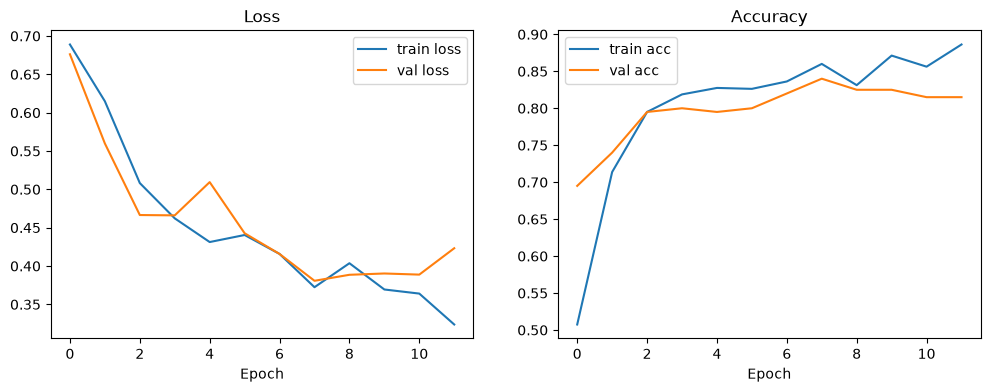

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'], label='train loss')
ax[0].plot(history.history['val_loss'], label='val loss')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train acc')
ax[1].plot(history.history['val_accuracy'], label='val acc')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()

plt.show()

## Try it out with Gradio

In [14]:
import gradio as gr
import numpy as np

def predict_sentiment(text):
    cleaned = preprocess(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    seq = pad_sequences(seq, padding='post', maxlen=maxlen)
    score = float(model.predict(np.array(seq), verbose=0)[0][0])
    label = 'Positive' if score >= 0.5 else 'Negative'
    return f"{label}"

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=2, placeholder='Type a review...'),
    outputs='text',
    title='Sentiment Analysis (LSTM)',
    examples=[
        ['did not like at all.'],
        ['nicest restaurant owners ive ever come across'],
        ['There is not a deal good enough that would drag me into that establishment again.']
    ]
)

demo.launch()

/home/chris/Documents/Broadway Python/Lesson 1/venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
